## LIME para imagenes

Para las imágenes, no es una buena idea perturbar píxeles individuales para comprender el comportamiento de nuestro modelo. Esto se debe a que mucho más de un solo píxel contribuye a definir una clase. Cambiar píxeles individuales de forma aleatoria probablemente no alteraría demasiado las predicciones.
Por lo tanto, las variaciones de las imágenes se crean segmentando la imagen en "superpíxeles" y activando o desactivando dichos superpíxeles. Hagamos un pequeño desvío para analizar brevemente este concepto.
Los algoritmos de superpíxeles agrupan los píxeles en regiones perceptualmente significativas mientras respetan los contornos potenciales de los objetos, reemplazando así la estructura rígida de la cuadrícula de píxeles. De manera más formal:

Superpíxel
Los superpíxeles son una sobresegmentación de una imagen. Un superpíxel es una agrupación perceptual de píxeles.

En lugar de buscar segmentos que correspondan a objetos completos (como se hace en la segmentación de instancias), los algoritmos de segmentación de superpíxeles dividen la imagen en lo que típicamente son unos cientos (por ejemplo, 2500) de segmentos.
El objetivo de esta sobresegmentación es particionar la imagen de tal manera que:
1) Ningún superpíxel quede dividido por el límite de un objeto.
2) Los objetos, en cambio, sí puedan estar divididos en múltiples superpíxeles.
El algoritmo LIME para imágenes utiliza los superpíxeles como características (features) de la imagen para interpretar un modelo de caja negra. Veamos cómo funciona.


## Configuraciones

Como siempre, comenzamos cargando los paquetes relevantes. Del paquete LIME, importamos lime_image. También hacemos uso del paquete skimage para la visualización. Consulta las instrucciones a continuación:

In [1]:
!pip install lime
#!pip install skimage

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=8f48fb8c9d6a736e0dc29fa9403b4f1a435cb0b1a4fa7d38be61b3ecbc685ede
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [2]:
import json
import os
import numpy as np
import PIL
from PIL import Image
import matplotlib.pyplot as plt

import torch
from torchvision.models import resnet18
import torchvision.transforms as T
import torch.nn.functional as F

# reading lime_image
from lime import lime_image

from skimage.segmentation import mark_boundaries

In [3]:
# Set random seed for reproducibility.
np.random.seed(0)
torch.manual_seed(0)

device ="cuda:0" if torch.cuda.is_available() else "cpu"

## Interpreta modelo ResNet

Nos enfocamos en interpretar el modelo ResNet. A continuación, cargamos el modelo. También necesitamos las descripciones de las clases del conjunto de datos ImageNet en el que se entrenó ResNet. Esta información está disponible en un archivo JSON que, del mismo modo, leemos a continuación.

In [4]:
# loading the model
import torch

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Now your code will work perfectly!
resnet = resnet18(pretrained=True)
resnet = resnet.eval().to(device)

# reading imagenet classes
idx2label, cls2label, cls2idx = [], {}, {}
with open("imagenet_class_index.json", 'r') as read_file:
    class_idx = json.load(read_file)
    idx2label = [class_idx[str(k)][1] for k in range(len(class_idx))]
    cls2label = {class_idx[str(k)][0]: class_idx[str(k)][1] for k in range(len(class_idx))}
    cls2idx = {class_idx[str(k)][0]: k for k in range(len(class_idx))}

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 144MB/s]


### Funciones Utilitarios

También necesitamos una función para convertir una imagen en un tensor de Torch sin normalizar. Este último se utiliza con el paquete LIME.

In [5]:
# resize and take the center part of image to what our model expects
def pil_to_torch(img):
    transf = T.Compose([
        T.Resize((256, 256)),
        T.CenterCrop(224),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])
    ])
    # unsqeeze converts single image to batch of 1
    return transf(img).unsqueeze(0)

def pil_transform(img):
    transf = T.Compose([
        T.Resize((256, 256)),
        T.CenterCrop(224)
    ])

    return transf(img)

### Función utilitaria para LIME

Necesitamos escribir una función auxiliar (o utilitaria) para trabajar con LIME. LIME nos proporcionará imágenes donde los superpíxeles se activan y desactivan, y requiere predicciones en forma de probabilidades de clase para entrenar su modelo local. Por lo tanto, necesitamos escribir una función que reciba las imágenes en forma de arreglos de NumPy (numpy arrays) y realice las predicciones utilizando nuestro modelo ResNet.

In [6]:
def cnn_predict(images):
    transf = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])
        ])

    batch = torch.stack(tuple(transf(img) for img in images), dim=0)

    logits = resnet(batch.to(device)).cpu()
    probs = F.softmax(logits, dim=1)
    return probs.detach().cpu().numpy()

### Lee una imagen

A continuación, leemos la imagen "puppy_kitten.jpg" desde la carpeta de datos y la mostramos.

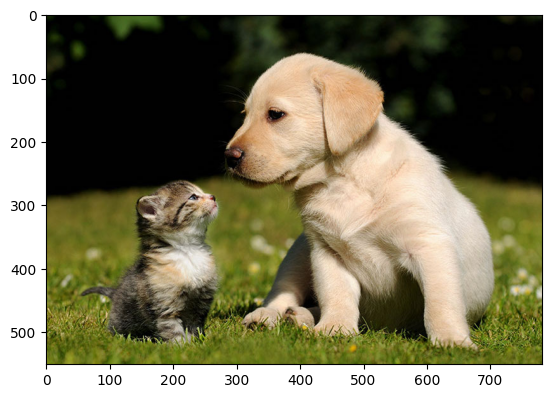

In [7]:
img_file_name = "puppy_kitten.jpg"
img_pil_0 = Image.open(img_file_name).convert('RGB')

_ = plt.imshow(img_pil_0)

### ResNet predicts as?

Let's see how the ResNet will recognize the image, is it a cat or a dog?

In [8]:
img0 = pil_to_torch(img_pil_0)

logits = resnet(img0.to(device))
probs = F.softmax(logits, dim=1).cpu()
probs5 = probs.topk(5)
tuple((p,c, idx2label[c]) for p, c in zip(probs5[0][0].detach().numpy(), probs5[1][0].detach().numpy()))

((np.float32(0.49324954), np.int64(208), 'Labrador_retriever'),
 (np.float32(0.2663804), np.int64(207), 'golden_retriever'),
 (np.float32(0.063391745), np.int64(222), 'kuvasz'),
 (np.float32(0.032333396), np.int64(257), 'Great_Pyrenees'),
 (np.float32(0.02384802), np.int64(170), 'Irish_wolfhound'))

### Usa LIME para explicar ResNet

Para utilizar LIME, primero debemos definir un objeto explicador (explainer). Consulta la celda de abajo para este propósito. Luego, podemos usar el método explain_instance desde el objeto explicador para comprender el comportamiento de ResNet. Ejecuta explain_instance y analiza los resultados.

In [9]:
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(np.array(pil_transform(img_pil_0)),
                                         cnn_predict, # classification function
                                         top_labels=2,
                                         hide_color=0,
                                         num_samples=1000) # number of images that will be sent to classification function

  0%|          | 0/1000 [00:00<?, ?it/s]

Después de ejecutar LIME en nuestra imagen, puede utilizar varios métodos para visualizar qué partes de la imagen contribuyeron a las decisiones. Consulta el método get_image_and_mask, el cual se puede utilizar para visualizar los superpíxeles que contribuyen positivamente o negativamente a la predicción de la etiqueta.

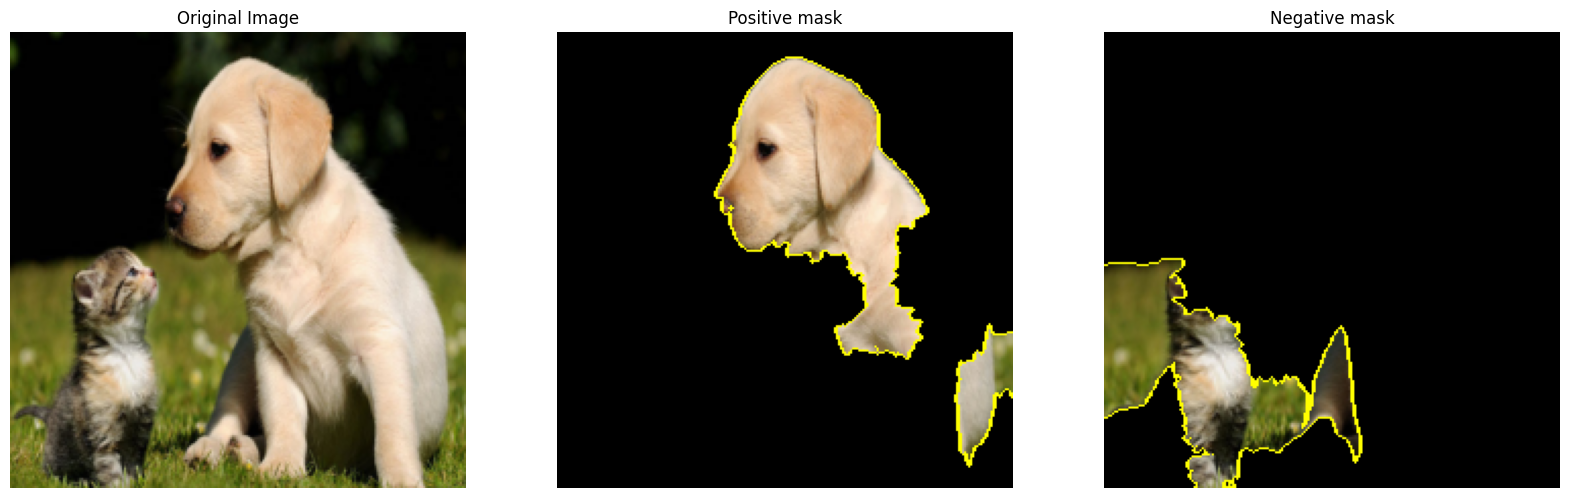

In [10]:
fig, axes = plt.subplots(1,3, figsize=(20, 10))

axes[0].imshow(pil_transform(img_pil_0))
axes[0].axis('off')
axes[0].set_title("Original Image")

temp, mask = explanation.get_image_and_mask(explanation.top_labels[0],
                                            positive_only=True, negative_only=False,
                                            num_features=5, hide_rest=True)

img_boundry = mark_boundaries(temp/255.0, mask)
axes[1].imshow(img_boundry)
axes[1].set_title("Positive mask")
axes[1].axis('off')

temp, mask = explanation.get_image_and_mask(explanation.top_labels[0],
                                            positive_only=False, negative_only=True,
                                            num_features=5, hide_rest=True)

img_boundry = mark_boundaries(temp/255.0, mask)
axes[2].imshow(img_boundry)
axes[2].set_title("Negative mask")
axes[2].axis('off')

plt.show()

## Ahora tratemos otra imagen!

In [12]:
img_file_name = "fruit.jpg"
img_pil_1 = Image.open(img_file_name).convert('RGB')

img1 = pil_to_torch(img_pil_1)
logits = resnet(img1.to(device)).cpu()
probs = F.softmax(logits, dim=1)
probs5 = probs.topk(5)

((np.float32(0.6809094), np.int64(588), 'hamper'),
 (np.float32(0.1597894), np.int64(790), 'shopping_basket'),
 (np.float32(0.03577311), np.int64(954), 'banana'),
 (np.float32(0.03574777), np.int64(951), 'lemon'),
 (np.float32(0.027241362), np.int64(953), 'pineapple'))

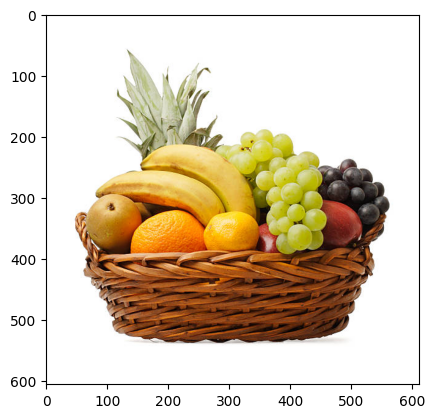

In [13]:
_ = plt.imshow(img_pil_1)
labels = tuple((p,c, idx2label[c]) for p, c in zip(probs5[0][0].detach().numpy(), probs5[1][0].detach().numpy()))
labels

In [14]:
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(np.array(pil_transform(img_pil_1)),
                                         cnn_predict, # classification function
                                         top_labels=5,
                                         hide_color=0,
                                         num_samples=1000) # number of images that will be sent to classification function


  0%|          | 0/1000 [00:00<?, ?it/s]

Looking at: lemon


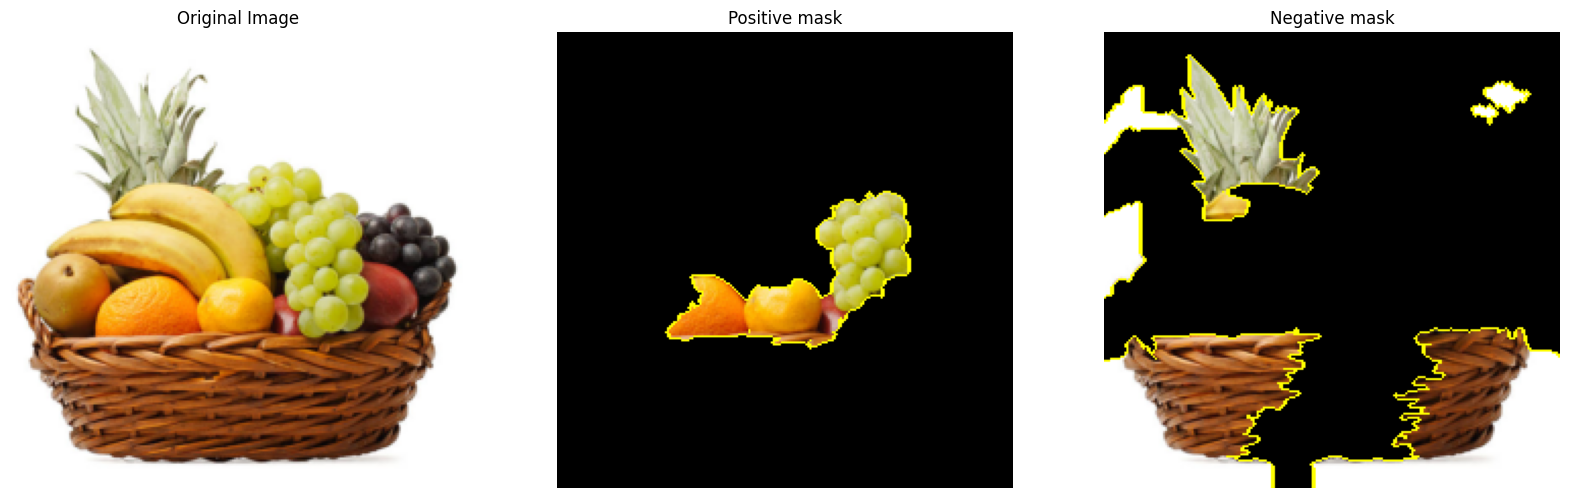

In [15]:
label = 3
print("Looking at:", labels[label][-1])

fig, axes = plt.subplots(1,3, figsize=(20, 10))
axes[0].imshow(pil_transform(img_pil_1))
axes[0].axis('off')
axes[0].set_title("Original Image")

temp, mask = explanation.get_image_and_mask(explanation.top_labels[label], positive_only=True,
                                            negative_only=False, num_features=3, hide_rest=True)
img_boundry = mark_boundaries(temp/255.0, mask)
axes[1].imshow(img_boundry)
axes[1].set_title("Positive mask")
axes[1].axis('off')

temp, mask = explanation.get_image_and_mask(explanation.top_labels[label], positive_only=False,
                                            negative_only=True, num_features=10, hide_rest=True)

img_boundry = mark_boundaries(temp/255.0, mask)
axes[2].imshow(img_boundry)
axes[2].set_title("Negative mask")
axes[2].axis('off')

plt.show()